In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv('apartments_preprocessed_data.csv')


In [3]:
df["location_type"].unique()


array([nan, 'Centrum obce', 'Klidná část obce', 'Okraj obce', 'Sídliště',
       'Rušná část obce', 'Polosamota'], dtype=object)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

known_data = df[df["location_type"].notna()]
missing_data = df[df["location_type"].isna()]

if not missing_data.empty:
    knn = KNeighborsClassifier(n_neighbors=3)

    knn.fit(known_data[["latitude", "longitude"]], known_data["location_type"])
    
    predictions = knn.predict(missing_data[["latitude", "longitude"]])
    df.loc[df["location_type"].isna(), "location_type"] = predictions

print(f"Unique values after filling: {df['location_type'].unique()}")

Unique values after filling: ['Klidná část obce' 'Centrum obce' 'Okraj obce' 'Sídliště'
 'Rušná část obce' 'Polosamota']


In [5]:
df_scoped = df[df['price_total'].between(df['price_total'].quantile(0.05), df['price_total'].quantile(0.95))]
df_scoped = df_scoped[df_scoped['total_area_m2'].between(df_scoped['total_area_m2'].quantile(0.0), df_scoped['total_area_m2'].quantile(0.90))]


In [6]:
df_scoped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9117 entries, 0 to 11245
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               9117 non-null   object 
 1   description         9117 non-null   object 
 2   category_sub        9117 non-null   object 
 3   price_total         9117 non-null   int64  
 4   street              9117 non-null   object 
 5   locality_region_id  9117 non-null   int64  
 6   district_id         9117 non-null   int64  
 7   latitude            9117 non-null   float64
 8   longitude           9117 non-null   float64
 9   usable_area_m2      9117 non-null   int64  
 10  total_area_m2       9117 non-null   float64
 11  loggia_area_m2      9117 non-null   float64
 12  cellar_area_m2      9117 non-null   float64
 13  floor_number        9117 non-null   float64
 14  total_floors        9117 non-null   float64
 15  construction_type   9117 non-null   object 
 16  building_c

In [7]:
df_scoped['is_furnished'].unique()

array(['0', 'Částečně', 'false', 'true'], dtype=object)

In [8]:
df_scoped['energy_class'].unique()

array(['B', 'G', 'D', 'C', 'unknown', 'E', 'A', 'F'], dtype=object)

In [9]:
cols_to_convert = df_scoped.select_dtypes(include=['object']).columns.tolist()

if 'location_type' in cols_to_convert:
    cols_to_convert.remove('location_type')

# Convert to category dtype
for col in cols_to_convert:
    df_scoped[col] = df_scoped[col].astype('category')

In [10]:
X = df_scoped.drop(['price_total','meta_description','title','description','street'], axis=1)
y = np.log1p(df_scoped['price_total']) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.26, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [11]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.05,
    depth=7,
    loss_function='RMSE',
    random_seed=42,
    verbose=500,
    cat_features = [
    'category_sub', 'building_condition', 'ownership_type', 
    'is_furnished', 'location_type', 'construction_type', 'locality_region_id'
    , 'energy_class'
]
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_val)
y_pred_real = np.expm1(y_pred_cat)
y_val_real = np.expm1(y_val)

print(f"CatBoost R2: {r2_score(y_val, y_pred_cat):.4f}")
print(f"CatBoost MAE: {mean_absolute_error(y_val_real, y_pred_real):,.0f} CZK")

/opt/anaconda3/envs/eda_env/lib/python3.12/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


0:	learn: 0.4716261	total: 61.2ms	remaining: 4m 4s
500:	learn: 0.1487038	total: 2.33s	remaining: 16.3s
1000:	learn: 0.1202186	total: 4.8s	remaining: 14.4s
1500:	learn: 0.1032020	total: 6.94s	remaining: 11.5s
2000:	learn: 0.0905367	total: 9.16s	remaining: 9.15s
2500:	learn: 0.0812910	total: 11.4s	remaining: 6.85s
3000:	learn: 0.0729401	total: 13.8s	remaining: 4.6s
3500:	learn: 0.0658891	total: 16.4s	remaining: 2.34s
3999:	learn: 0.0598742	total: 18.6s	remaining: 0us
CatBoost R2: 0.8801
CatBoost MAE: 772,410 CZK


In [12]:

district_means = y_train.groupby(X_train['district_id']).mean()
X_train['district_id'] = X_train['district_id'].map(district_means)
X_test['district_id'] = X_test['district_id'].map(district_means)
X_val['district_id'] = X_val['district_id'].map(district_means)

X_test['district_id'] = X_test['district_id'].fillna(y_train.mean())
X_val['district_id'] = X_val['district_id'].fillna(y_train.mean())
print(X_test['district_id'].sort_values().unique())
cat_features = [
    'category_sub', 'building_condition', 'ownership_type', 
    'is_furnished', 'location_type', 'construction_type', 'locality_region_id'
]

num_features = [
    'usable_area_m2', 'total_area_m2', 'loggia_area_m2', 
    'cellar_area_m2', 'floor_number', 'total_floors',
    'latitude', 'longitude', 'district_id'
]

bool_features = ['has_elevator', 'has_garage', 'has_cellar', 'has_terrace', 'has_loggia']

energy_order = [['unknown', 'G', 'F', 'E', 'D', 'C', 'B', 'A']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ('energy', OrdinalEncoder(categories=energy_order), ['energy_class']),
        ('bool', 'passthrough', bool_features)
    ])



[14.77244708 14.79390801 14.85504183 14.85874193 14.87920973 14.9415802
 14.96219204 14.98816178 14.99559803 15.00277519 15.04262965 15.04543302
 15.07117279 15.0862632  15.10528393 15.10937497 15.11180881 15.12902672
 15.13043453 15.1410025  15.15332909 15.16263043 15.2059175  15.21146069
 15.21762143 15.22267243 15.22368614 15.22457982 15.2325976  15.2346113
 15.240972   15.24231244 15.24756364 15.25368627 15.26595151 15.28323327
 15.28746003 15.29027759 15.30185275 15.31615598 15.32567945 15.33635825
 15.34793341 15.35120449 15.36176365 15.3827357  15.38559819 15.40698192
 15.41251726 15.41287869 15.42084219 15.42659441 15.43651267 15.47240827
 15.48031266 15.48533241 15.49073072 15.50059738 15.50308353 15.50518642
 15.50777881 15.50779113 15.5316652  15.53343265 15.53566133 15.54002974
 15.54050493 15.5536464  15.55614656 15.62316821 15.64186748 15.67678905
 15.69973315 15.78745037 15.8411095  15.85382197 15.9465952  15.97181968
 15.97803512 16.01659215 16.02575294 16.06401424 16.0

In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6746 entries, 69 to 8895
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   category_sub        6746 non-null   category
 1   locality_region_id  6746 non-null   int64   
 2   district_id         6746 non-null   float64 
 3   latitude            6746 non-null   float64 
 4   longitude           6746 non-null   float64 
 5   usable_area_m2      6746 non-null   int64   
 6   total_area_m2       6746 non-null   float64 
 7   loggia_area_m2      6746 non-null   float64 
 8   cellar_area_m2      6746 non-null   float64 
 9   floor_number        6746 non-null   float64 
 10  total_floors        6746 non-null   float64 
 11  construction_type   6746 non-null   category
 12  building_condition  6746 non-null   category
 13  ownership_type      6746 non-null   category
 14  location_type       6746 non-null   object  
 15  energy_class        6746 non-null   catego

In [14]:
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

print(f"Final shape of processed training data: {X_train.shape}")
print(f"Final shape of processed test data: {X_val.shape}")

Final shape of processed training data: (6746, 64)
Final shape of processed test data: (1185, 64)


In [ ]:

def plot_regression_enhanced(y_true_log, y_pred_log):
    
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color='teal')
    
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', lw=2, linestyle='--')
    
    stats_text = f'R² Score: {r2:.3f}\nMAE: ${mae:,.0f}'
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                   fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.title('Real vs Predicted (with Metrics)')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.show()

In [16]:
LR_model = LinearRegression()

LR_model.fit(X_train, y_train)

y_pred = LR_model.predict(X_val)
print(f"R-squared: {r2_score(y_val, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_val, y_pred):.2f} CZK")

R-squared: 0.7810
MAE: 0.17 CZK


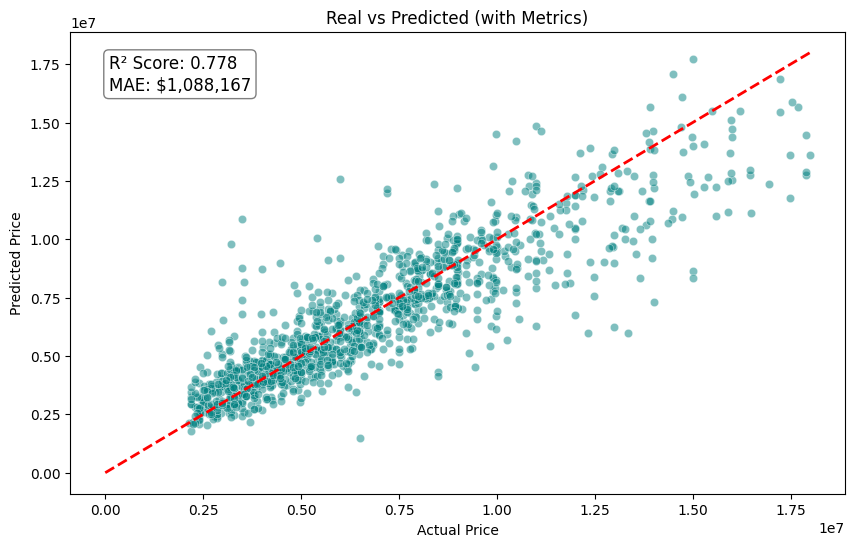

In [17]:
plot_regression_enhanced(y_val, y_pred)

In [18]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_val)
y_pred_real = np.expm1(y_pred_tree)
y_val_real = np.expm1(y_val)

print(f"Tree R2: {r2_score(y_val, y_pred_tree):.4f}")
print(f"Tree MAE: {mean_absolute_error(y_val_real, y_pred_real):,.0f} CZK")

Tree R2: 0.7642
Tree MAE: 1,126,557 CZK


In [21]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=7, weights='distance')
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_val)
y_pred_real_knn = np.expm1(y_pred_knn)

print(f"KNN R2: {r2_score(y_val, y_pred_knn):.4f}")
print(f"KNN MAE: {mean_absolute_error(y_val_real, y_pred_real_knn):,.0f} CZK")

KNN R2: 0.7648
KNN MAE: 1,085,305 CZK


In [ ]:
from sklearn.kernel_ridge import KernelRidge

param_grid_krr = {
    'alpha': [0.1, 1.0, 10.0],
    'kernel': ['polynomial', 'rbf'],
    'gamma': [0.01, 0.1, 1.0],
    'degree': [2, 3, 4, 5]
}

krr_model = GridSearchCV(
    KernelRidge(),
    param_grid=param_grid_krr,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

krr_model.fit(X_train, y_train)

print(f"Best KRR Parameters: {krr_model.best_params_}")
print(f"Best KRR R2 Score: {krr_model.best_score_:.4f}")

/opt/anaconda3/envs/eda_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:237: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.4111681621895494e-16.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/anaconda3/envs/eda_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:237: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1854055937047243e-16.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Best KRR Parameters: {'alpha': 0.1, 'degree': 2, 'gamma': 0.01, 'kernel': 'polynomial'}
Best KRR R2 Score: 0.8297


In [23]:
best_krr = krr_model.best_estimator_
y_pred_krr = best_krr.predict(X_val)

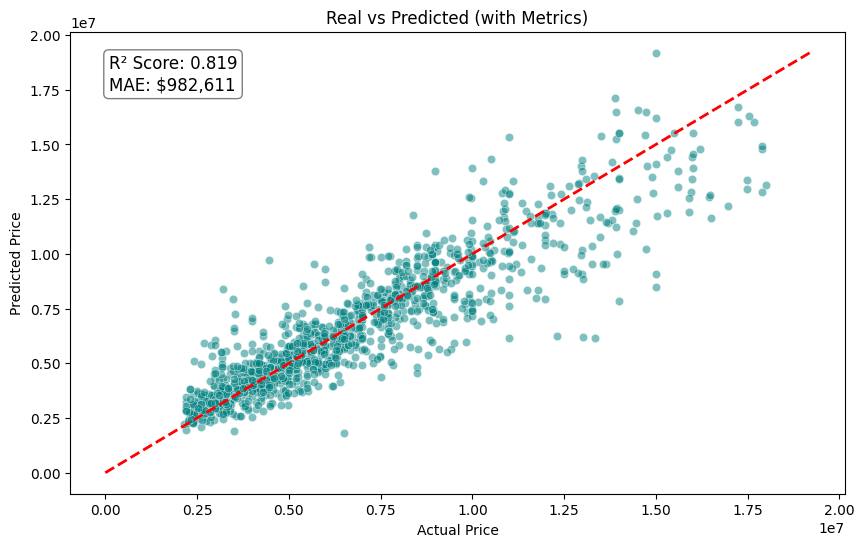

In [24]:
plot_regression_enhanced(y_val, y_pred_krr)

In [ ]:
from xgboost import XGBRegressor
param_grid = {
    'n_estimators': [100, 200, 300], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 5, 7, None],
    'reg_alpha': [0, 0.1, 0.5]
}
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',   
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

best_model_XGB = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")


/opt/anaconda3/envs/eda_env/lib/python3.12/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/envs/eda_env/lib/python3.12/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/envs/eda_env/lib/python3.12/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Set

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0.1}


In [27]:
best_model_XGB.fit(X_train, y_train)

y_pred=best_model_XGB.predict(X_val)
print(f"R-squared: {r2_score(y_val, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_val, y_pred):.2f} CZK")
y_exp = np.expm1(y_val)
y_pred_exp = np.expm1(y_pred)
print(f"MAPE: {mean_absolute_percentage_error(y_exp, y_pred_exp):.4f}")

R-squared: 0.8739
MAE: 0.12 CZK
MAPE: 0.1243


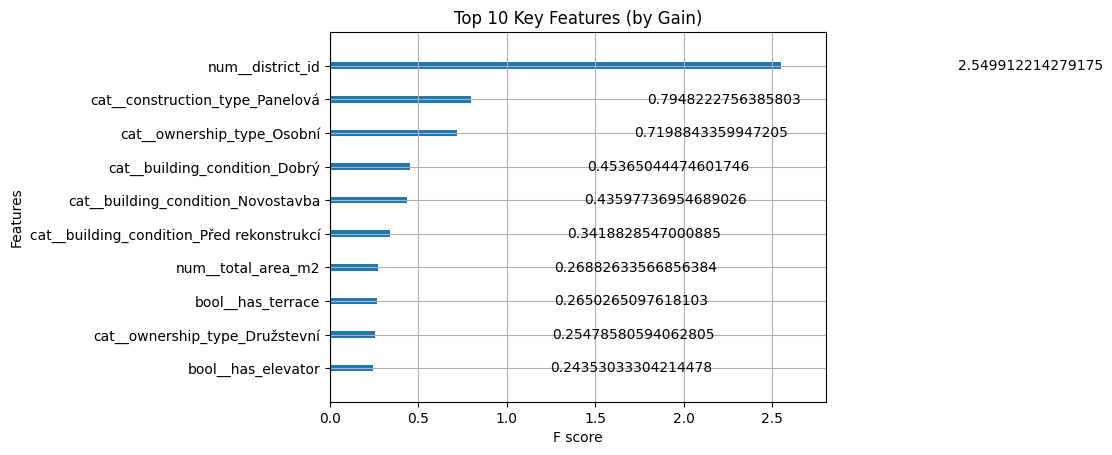

In [31]:
from xgboost import plot_importance
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

best_model_XGB.fit(X_train_df, y_train)
plot_importance(best_model_XGB, importance_type='gain', max_num_features=10)
plt.title("Top 10 Key Features (by Gain)")
plt.show()


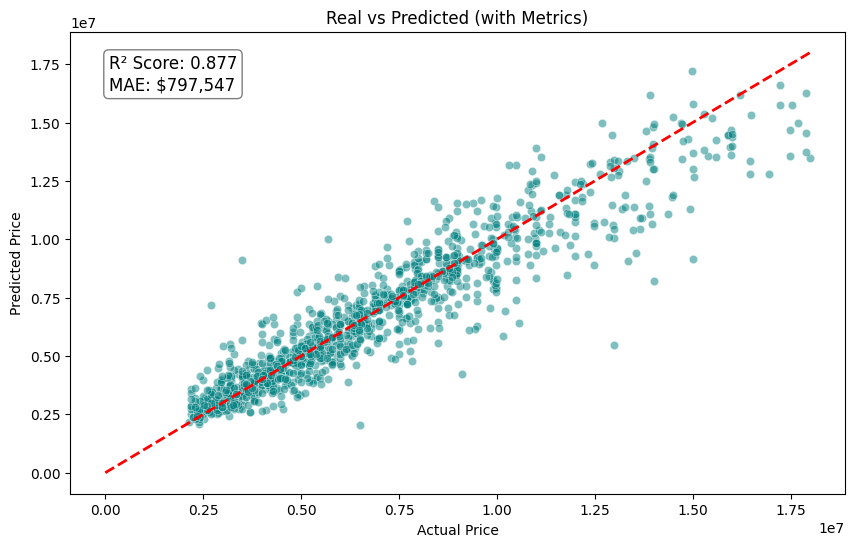

In [32]:
plot_regression_enhanced(y_val, y_pred)

In [33]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [10, 15, 20, None], 
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2', None] 
}
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    scoring='r2',
    n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

best_model_rf = grid_search_rf.best_estimator_
print(f"Best Parameters: {grid_search_rf.best_params_}")
y_pred_rf = best_model_rf.predict(X_val)

print(f"Random Forest R-squared: {r2_score(y_val, y_pred_rf):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_val, y_pred_rf):.2f} CZK")

/opt/anaconda3/envs/eda_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Random Forest R-squared: 0.8501
Random Forest MAE: 0.13 CZK


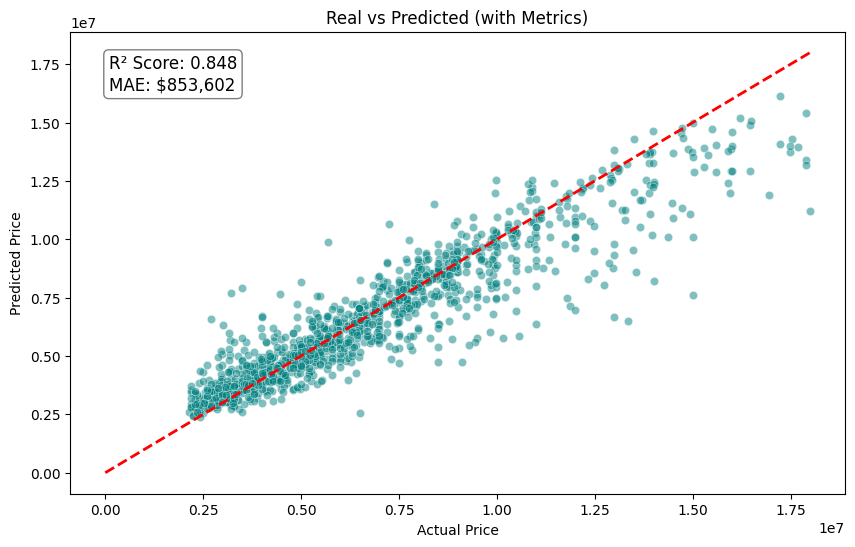

In [34]:
plot_regression_enhanced(y_val, y_pred_rf)
